# (V3) Sector Quintile Forward Return Analysis

2020-01 이후 데이터를 기준으로,
- PBR TS Z-Score 5분위
- MOM TS Z-Score 5분위

를 각각 구성하고, 분위별 미래 수익률(1M, 3M, 6M, 12M) 추세를 분석합니다.

> 핵심 규칙
> - 신호 산출 시점: 월말
> - 분위 분류: 해당 월 단면에서 산업별 5분위
> - 성과 측정: 같은 월말 기준 미래 $h$개월 수익률

In [24]:
# !pip install seaborn

In [25]:
import warnings
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(42)

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

BASE_DIR = Path.cwd()
PBR_PATH = BASE_DIR / "krx_sector_pbr.csv"
PRICE_PATH = BASE_DIR / "kodex_sector_etf_close.csv"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# 전체 가용 기간 사용. 특정 시작일을 쓰려면 pd.Timestamp("YYYY-MM-DD")로 변경.
START_DATE = None
QUINTILES = 5
TS_Z_WINDOW = 252 * 2      # 일 단위 롤링 윈도우 (약 2년)
MOM_LOOKBACK = 252         # 일 단위 12개월 모멘텀
HORIZONS = [1, 3, 6, 12]   # 미래 수익률 (월 기준)
LABELS = [f"Q{i}" for i in range(1, QUINTILES + 1)]

EXCLUDED_SECTORS = []
SECTOR_ALIAS_MAP = {
    "IT": "정보기술",
    "K콘텐츠": "K콘텐츠",
}
BENCHMARK_NAME = "섹터평균"


def normalize_sector_name(name: str) -> str:
    s = str(name).strip()
    s = re.sub(r"^KODEX\s+", "", s)
    s = re.sub(r"^KRX\s+", "", s)
    s = re.sub(r"\s+", "", s)
    return SECTOR_ALIAS_MAP.get(s, s)


print("BASE_DIR:", BASE_DIR)
print("START_DATE:", START_DATE)
print("PBR_PATH:", PBR_PATH.name)
print("PRICE_PATH:", PRICE_PATH.name)
print("Excluded sectors:", EXCLUDED_SECTORS)

BASE_DIR: /workspaces/KR-Ind-Quant-Dashboard
START_DATE: None
PBR_PATH: krx_sector_pbr.csv
PRICE_PATH: kodex_sector_etf_close.csv
Excluded sectors: []


## 1) 데이터 로드 및 기간 필터링 (2020-01 이후)

- 일별 원천 데이터를 로드합니다.
- 월말(해당 월 마지막 거래일) 패널로 변환합니다.
- 2020-01 이후 구간만 사용합니다.

In [26]:
def to_month_end(df: pd.DataFrame) -> pd.DataFrame:
    temp = df.copy().sort_index()
    temp["year_month"] = temp.index.to_period("M")
    month_end = temp.groupby("year_month", as_index=False).tail(1).drop(columns=["year_month"])
    month_end.index = month_end.index.to_period("M").to_timestamp("M")
    return month_end.sort_index()


pbr_raw = pd.read_csv(PBR_PATH, parse_dates=["날짜"]).rename(columns={"날짜": "date"}).sort_values("date").set_index("date")
price_raw = pd.read_csv(PRICE_PATH, parse_dates=["날짜"]).rename(columns={"날짜": "date"}).sort_values("date").set_index("date")

pbr_raw = pbr_raw.rename(columns={c: normalize_sector_name(c) for c in pbr_raw.columns})
price_raw = price_raw.rename(columns={c: normalize_sector_name(c) for c in price_raw.columns})

# 공통 산업 컬럼 + 공통 거래일 사용
common_sectors_all = sorted(set(pbr_raw.columns).intersection(price_raw.columns))
common_sectors = [s for s in common_sectors_all if s not in EXCLUDED_SECTORS]

pbr_d = pbr_raw[common_sectors].copy()
price_d = price_raw[common_sectors].copy()

# PBR 데이터가 존재하는 날짜까지만 가격 데이터 사용
common_dates = pbr_d.index.intersection(price_d.index)
pbr_d = pbr_d.loc[common_dates].sort_index()
price_d = price_d.loc[common_dates].sort_index()

# 월말 거래일 인덱스는 일별 데이터에서 산출
month_end_idx = (
    price_d.groupby(price_d.index.to_period("M"))
    .apply(lambda x: x.index.max())
)
month_end_idx = pd.DatetimeIndex(month_end_idx.values).sort_values()

pbr_m = pbr_d.loc[month_end_idx].copy()
price_m = price_d.loc[month_end_idx].copy()

# START_DATE가 데이터 가용 구간 밖이면 자동 보정
effective_start_date = START_DATE
if START_DATE is not None and not price_m.empty:
    data_min = price_m.index.min()
    data_max = price_m.index.max()

    if START_DATE > data_max:
        effective_start_date = data_min
        print(
            f"[WARN] START_DATE({START_DATE.date()})가 데이터 마지막({data_max.date()}) 이후입니다. "
            f"{effective_start_date.date()}로 자동 조정합니다."
        )
    elif START_DATE < data_min:
        effective_start_date = data_min

if effective_start_date is not None:
    pbr_m = pbr_m.loc[pbr_m.index >= effective_start_date]
    price_m = price_m.loc[price_m.index >= effective_start_date]

print("pbr_raw shape:", pbr_raw.shape)
print("price_raw shape:", price_raw.shape)
print("common sectors:", len(common_sectors))
print("aligned daily range:", pbr_d.index.min().date(), "~", pbr_d.index.max().date())
print("effective_start_date:", effective_start_date.date() if effective_start_date is not None else None)
print("month-end samples:", len(price_m))
print("common sectors list:", common_sectors)
display(pbr_m.head(3))
display(price_m.head(3))

pbr_raw shape: (2243, 17)
price_raw shape: (3997, 15)
common sectors: 15
aligned daily range: 2010-01-04 ~ 2019-02-08
effective_start_date: None
month-end samples: 110
common sectors list: ['K콘텐츠', '건설', '경기소비재', '기계장비', '반도체', '보험', '에너지화학', '운송', '은행', '자동차', '정보기술', '증권', '철강', '필수소비재', '헬스케어']


,K콘텐츠,건설,경기소비재,기계장비,반도체,보험,에너지화학,운송,은행,자동차,정보기술,증권,철강,필수소비재,헬스케어
2010-01-29,NaN,1.55,NaN,1.25,1.81,1.98,1.58,1.22,1.03,1.43,NaN,1.23,1.30,NaN,2.19
2010-02-26,NaN,1.54,NaN,1.36,1.71,1.98,1.64,1.25,1.02,1.48,NaN,1.22,1.31,NaN,2.22
2010-03-31,NaN,1.58,NaN,1.53,1.92,1.97,1.75,1.37,1.13,1.52,NaN,1.24,1.31,NaN,2.30


,K콘텐츠,건설,경기소비재,기계장비,반도체,보험,에너지화학,운송,은행,자동차,정보기술,증권,철강,필수소비재,헬스케어
2010-01-29,NaN,5295.0,NaN,13745.0,14365.0,NaN,7545.0,NaN,8295.0,9945.0,NaN,8480.0,8310.0,NaN,NaN
2010-02-26,NaN,5225.0,NaN,14710.0,13895.0,NaN,7850.0,NaN,8220.0,10475.0,NaN,8365.0,8550.0,NaN,NaN
2010-03-31,NaN,5385.0,NaN,16460.0,15910.0,NaN,8340.0,NaN,8910.0,10835.0,NaN,8700.0,8855.0,NaN,NaN


## 2) 산업 패널 정리 및 지표 정합성 검증

- 중복 인덱스, 결측 비율, 최소 관측치 조건을 점검합니다.
- 이후 분위 분류와 미래수익률 계산에서 사용할 유효 표본 범위를 확인합니다.

## 2-1) 섹터 유니버스 재생성 및 Yahoo Finance 가격 검증

- `상업전문서비스`, `가정용품`을 유니버스에서 제외합니다.
- 섹터-ETF 매핑 엑셀 파일을 재생성합니다.
- Yahoo Finance에서 ETF 일별 가격을 직접 내려받아 로컬 산업 가격 데이터와 커버리지를 비교합니다.

In [27]:
# 1) 유니버스(필터 적용) 섹터 테이블 저장
universe_df = pd.DataFrame({"sector": common_sectors}).reset_index(drop=True)

universe_xlsx_path = OUTPUT_DIR / "sector_universe_filtered.xlsx"
universe_csv_path = OUTPUT_DIR / "sector_universe_filtered.csv"

xlsx_saved = False
try:
    universe_df.to_excel(universe_xlsx_path, index=False)
    xlsx_saved = True
except ModuleNotFoundError:
    print("openpyxl 미설치로 xlsx 저장은 건너뜁니다. (csv는 저장됩니다)")

universe_df.to_csv(universe_csv_path, index=False)

# 2) PBR/가격 데이터 커버리지 점검
pbr_cov = pbr_d.notna().mean().rename("pbr_non_na_ratio")
pbr_obs = pbr_d.notna().sum().rename("pbr_obs")
price_cov = price_d.notna().mean().rename("price_non_na_ratio")
price_obs = price_d.notna().sum().rename("price_obs")

coverage_rows = []
for sec in common_sectors:
    pbr_s = pbr_d[sec]
    px_s = price_d[sec]
    coverage_rows.append(
        {
            "sector": sec,
            "pbr_non_na_ratio": pbr_cov.get(sec, np.nan),
            "price_non_na_ratio": price_cov.get(sec, np.nan),
            "pbr_obs": pbr_obs.get(sec, 0),
            "price_obs": price_obs.get(sec, 0),
            "pbr_first_date": pbr_s.dropna().index.min(),
            "pbr_last_date": pbr_s.dropna().index.max(),
            "price_first_date": px_s.dropna().index.min(),
            "price_last_date": px_s.dropna().index.max(),
        }
    )

check_df = pd.DataFrame(coverage_rows)
check_df["coverage_gap_pbr_minus_price"] = check_df["pbr_non_na_ratio"] - check_df["price_non_na_ratio"]
check_df = check_df.sort_values("coverage_gap_pbr_minus_price", ascending=False).reset_index(drop=True)

print("Filtered universe saved:")
if xlsx_saved:
    print(universe_xlsx_path)
print(universe_csv_path)
print("\n[Coverage check: pbr vs price]")
display(check_df)

check_df.to_csv(OUTPUT_DIR / "price_data_coverage_validation.csv", index=False)
print("Validation file saved:", OUTPUT_DIR / "price_data_coverage_validation.csv")

openpyxl 미설치로 xlsx 저장은 건너뜁니다. (csv는 저장됩니다)
Filtered universe saved:
/workspaces/KR-Ind-Quant-Dashboard/outputs/sector_universe_filtered.csv

[Coverage check: pbr vs price]


,sector,pbr_non_na_ratio,price_non_na_ratio,pbr_obs,price_obs,pbr_first_date,pbr_last_date,price_first_date,price_last_date,coverage_gap_pbr_minus_price
0,헬스케어,1.000000,0.201962,2243,453,2010-01-04,2019-02-08,2017-03-28,2019-02-08,0.798038
1,보험,0.999108,0.853767,2241,1915,2010-01-04,2019-02-08,2011-04-26,2019-02-08,0.145341
2,운송,0.999108,0.853767,2241,1915,2010-01-04,2019-02-08,2011-04-26,2019-02-08,0.145341
3,K콘텐츠,0.260811,0.201962,585,453,2016-09-12,2019-02-08,2017-03-28,2019-02-08,0.058850
4,경기소비재,0.260811,0.201962,585,453,2016-09-12,2019-02-08,2017-03-28,2019-02-08,0.058850
5,정보기술,0.260811,0.201962,585,453,2016-09-12,2019-02-08,2017-03-28,2019-02-08,0.058850
6,필수소비재,0.260811,0.201962,585,453,2016-09-12,2019-02-08,2017-03-28,2019-02-08,0.058850
7,건설,1.000000,1.000000,2243,2243,2010-01-04,2019-02-08,2010-01-04,2019-02-08,0.000000
8,기계장비,1.000000,1.000000,2243,2243,2010-01-04,2019-02-08,2010-01-04,2019-02-08,0.000000
9,반도체,1.000000,1.000000,2243,2243,2010-01-04,2019-02-08,2010-01-04,2019-02-08,0.000000


Validation file saved: /workspaces/KR-Ind-Quant-Dashboard/outputs/price_data_coverage_validation.csv


In [28]:
dup_pbr = pbr_d.index.duplicated().sum()
dup_price = price_d.index.duplicated().sum()

missing_pbr = pbr_d.isna().mean().sort_values(ascending=False)
missing_price = price_d.isna().mean().sort_values(ascending=False)

print("duplicate index - pbr:", dup_pbr, ", price:", dup_price)
print("top 5 missing ratio (pbr):")
print(missing_pbr.head())
print("\ntop 5 missing ratio (price):")
print(missing_price.head())

# 최소 관측치 조건(일별 Z-Score + 월별 미래수익률 계산 안정성)
min_obs_needed = TS_Z_WINDOW + 21 * max(HORIZONS)
valid_day_count = len(pbr_d)
valid_month_count = len(price_m)
print(f"\nmin daily obs needed: {min_obs_needed}, available days: {valid_day_count}")
print(f"available month-end points: {valid_month_count}")

duplicate index - pbr: 0 , price: 0
top 5 missing ratio (pbr):
K콘텐츠     0.739189
경기소비재    0.739189
정보기술     0.739189
필수소비재    0.739189
보험       0.000892
dtype: float64

top 5 missing ratio (price):
K콘텐츠     0.798038
경기소비재    0.798038
정보기술     0.798038
필수소비재    0.798038
헬스케어     0.798038
dtype: float64

min daily obs needed: 756, available days: 2243
available month-end points: 110


## 3) 미래 수익률 계산 (1M, 3M, 6M, 12M)

산업별 월말 가격에서 다음 공식을 적용합니다.

$$
r_{t,t+h}=\frac{P_{t+h}}{P_t}-1
$$

여기서 $h \in \{1,3,6,12\}$ 입니다.

In [29]:
def rolling_zscore(panel: pd.DataFrame, window: int) -> pd.DataFrame:
    mean = panel.rolling(window=window, min_periods=max(252, window // 3)).mean()
    std = panel.rolling(window=window, min_periods=max(252, window // 3)).std()
    return (panel - mean) / (std + 1e-10)


# MOM 원신호: 일별 12개월 모멘텀
mom_signal_raw_daily = price_d.pct_change(MOM_LOOKBACK)

# TS Z-Score는 일별로 계산
pbr_ts_z_daily = rolling_zscore(pbr_d, TS_Z_WINDOW)
mom_ts_z_daily = rolling_zscore(mom_signal_raw_daily, TS_Z_WINDOW)

# 월말 분위 분석을 위해 월말 날짜만 스냅샷 추출
pbr_ts_z = pbr_ts_z_daily.loc[month_end_idx].copy()
mom_ts_z = mom_ts_z_daily.loc[month_end_idx].copy()

# 미래 수익률은 월말 가격 기준
forward_returns = {}
for h in HORIZONS:
    forward_returns[h] = price_m.shift(-h) / price_m - 1.0

print("pbr_ts_z_daily shape:", pbr_ts_z_daily.shape)
print("mom_ts_z_daily shape:", mom_ts_z_daily.shape)
print("pbr_ts_z(month-end) shape:", pbr_ts_z.shape)
print("mom_ts_z(month-end) shape:", mom_ts_z.shape)
print("forward 12m non-null:", forward_returns[12].notna().sum().sum())

pbr_ts_z_daily shape: (2243, 15)
mom_ts_z_daily shape: (2243, 15)
pbr_ts_z(month-end) shape: (110, 15)
mom_ts_z(month-end) shape: (110, 15)
forward 12m non-null: 1010


## 4) PBR / MOM TS Z-Score 기준 5분위 분류

각 월 단면에서 산업들을 5분위로 나눕니다.
동일값 과다 등으로 `qcut`이 실패하면 순위 기반 fallback 로직을 사용합니다.

In [30]:
def assign_quintiles_row(row: pd.Series, q: int = 5) -> pd.Series:
    out = pd.Series(index=row.index, dtype="object")
    valid = row.dropna()

    if len(valid) < q or valid.nunique() < 2:
        return out

    labels = [f"Q{i}" for i in range(1, q + 1)]
    try:
        bins = pd.qcut(valid, q=q, labels=labels, duplicates="drop")
        out.loc[bins.index] = bins.astype(str)
    except ValueError:
        ranked = valid.rank(method="first")
        q_eff = min(q, ranked.nunique())
        if q_eff < 2:
            return out
        bins = pd.qcut(ranked, q=q_eff, labels=labels[:q_eff], duplicates="drop")
        out.loc[bins.index] = bins.astype(str)

    return out


pbr_quintile = pbr_ts_z.apply(assign_quintiles_row, axis=1, q=QUINTILES)
mom_quintile = mom_ts_z.apply(assign_quintiles_row, axis=1, q=QUINTILES)

print("pbr quintile valid obs:", pbr_quintile.notna().sum().sum())
print("mom quintile valid obs:", mom_quintile.notna().sum().sum())

pbr quintile valid obs: 1150
mom quintile valid obs: 828


## 5) 분위별 미래 수익률 집계 시계열 생성

PBR 기반과 MOM 기반을 각각 집계합니다.
- 평균
- 중앙값
- 표준편차
- 관측치 수

In [31]:
def panel_to_long(signal_df: pd.DataFrame, q_df: pd.DataFrame, ret_dict: dict[int, pd.DataFrame], signal_name: str) -> pd.DataFrame:
    frames = {
        signal_name: signal_df.stack(dropna=False),
        f"{signal_name}_q": q_df.stack(dropna=False),
    }
    for h, ret in ret_dict.items():
        frames[f"fwd_{h}m"] = ret.stack(dropna=False)

    long_df = pd.concat(frames, axis=1).reset_index()
    long_df = long_df.rename(columns={"level_0": "date", "level_1": "sector"})
    return long_df


def aggregate_quintile_timeseries(long_df: pd.DataFrame, q_col: str) -> pd.DataFrame:
    ret_cols = [c for c in long_df.columns if c.startswith("fwd_") and c.endswith("m")]

    melted = long_df.melt(
        id_vars=["date", "sector", q_col],
        value_vars=ret_cols,
        var_name="horizon",
        value_name="fwd_return",
    ).dropna(subset=[q_col, "fwd_return"])

    agg = (
        melted.groupby(["date", q_col, "horizon"], as_index=False)
        .agg(
            mean_return=("fwd_return", "mean"),
            median_return=("fwd_return", "median"),
            std_return=("fwd_return", "std"),
            n_obs=("fwd_return", "count"),
        )
    )

    return agg


pbr_long = panel_to_long(pbr_ts_z, pbr_quintile, forward_returns, "pbr_ts_z")
mom_long = panel_to_long(mom_ts_z, mom_quintile, forward_returns, "mom_ts_z")

pbr_agg_ts = aggregate_quintile_timeseries(pbr_long, "pbr_ts_z_q")
mom_agg_ts = aggregate_quintile_timeseries(mom_long, "mom_ts_z_q")

display(pbr_agg_ts.head())
display(mom_agg_ts.head())

,date,pbr_ts_z_q,horizon,mean_return,median_return,std_return,n_obs
0,2011-01-31,Q1,fwd_12m,0.004953,0.004953,NaN,1
1,2011-01-31,Q1,fwd_1m,-0.005778,-0.005778,NaN,1
2,2011-01-31,Q1,fwd_3m,0.166735,0.166735,NaN,1
3,2011-01-31,Q1,fwd_6m,0.201816,0.201816,NaN,1
4,2011-01-31,Q2,fwd_12m,0.024153,0.024153,0.261613,2


,date,mom_ts_z_q,horizon,mean_return,median_return,std_return,n_obs
0,2012-01-31,Q1,fwd_12m,-0.139720,-0.139720,0.032359,2
1,2012-01-31,Q1,fwd_1m,0.089031,0.089031,0.115542,2
2,2012-01-31,Q1,fwd_3m,0.067741,0.067741,0.090818,2
3,2012-01-31,Q1,fwd_6m,-0.044363,-0.044363,0.132721,2
4,2012-01-31,Q2,fwd_12m,-0.194421,-0.194421,NaN,1


## 6) PBR 5분위 성과 추세 시각화

각 horizon(1M/3M/6M/12M) 별로 분위 포트폴리오 평균 미래수익률을 누적해 추세를 확인합니다.

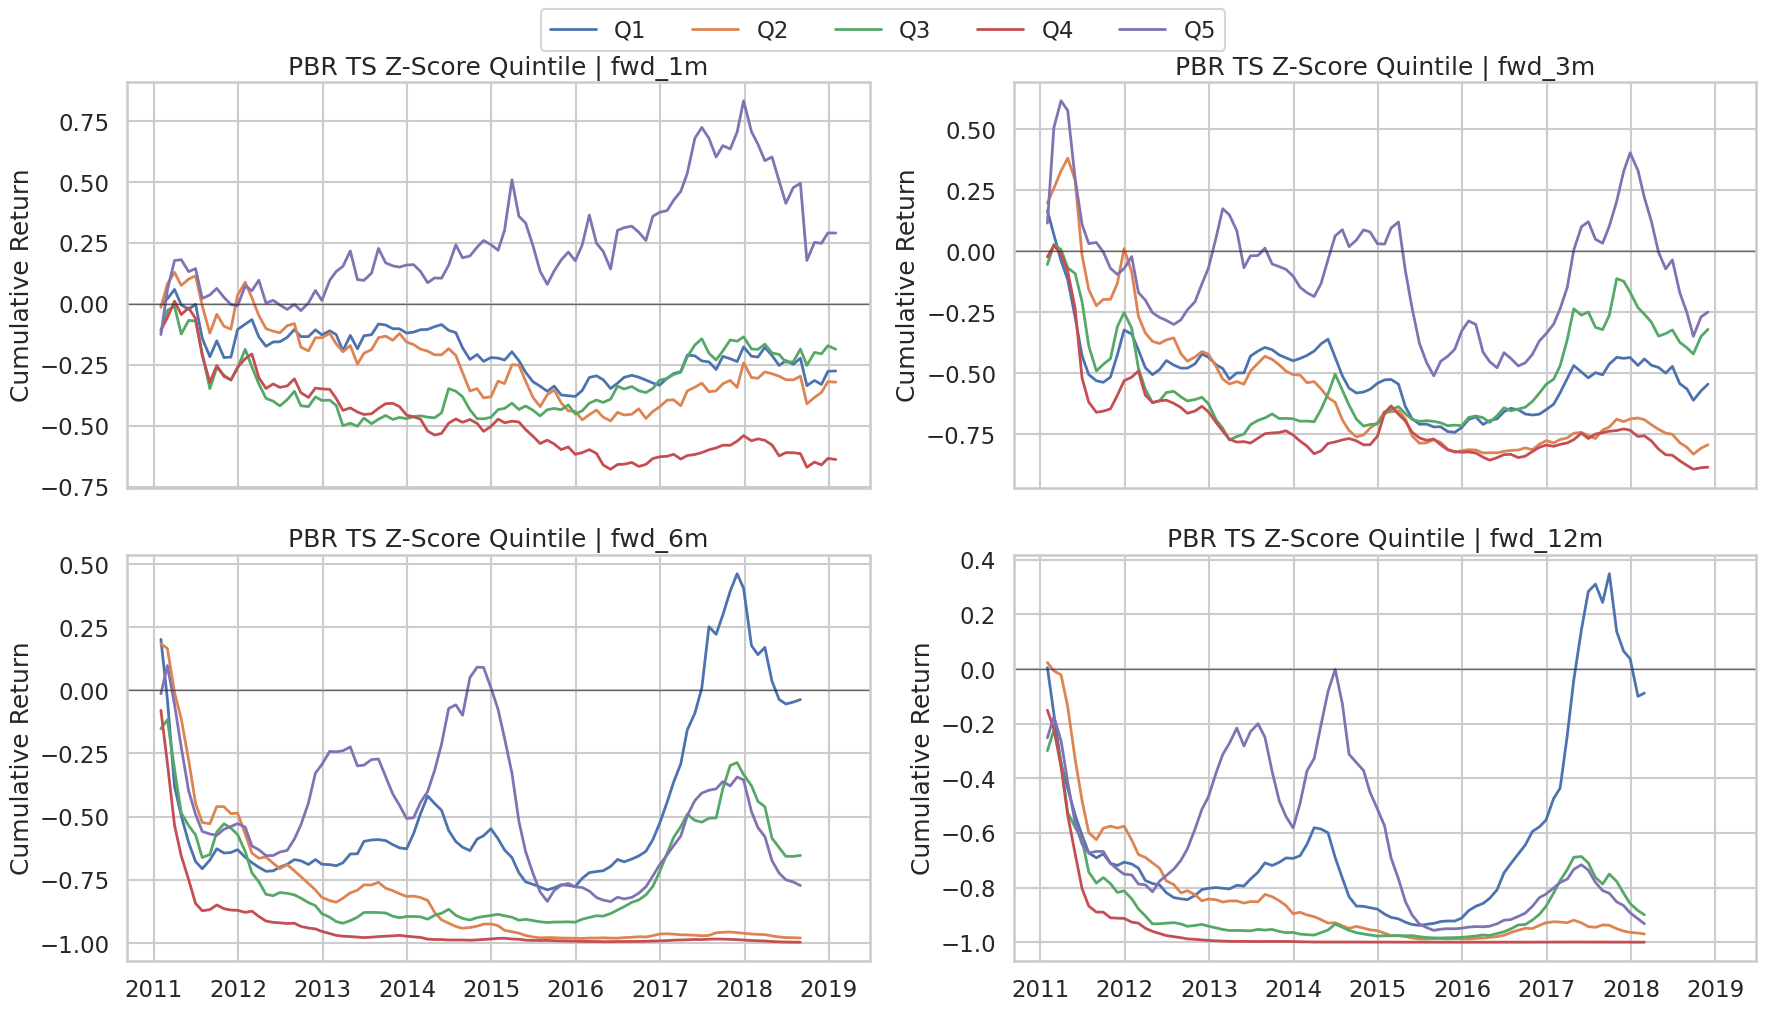

In [32]:
def plot_quintile_trend(agg_ts: pd.DataFrame, q_col: str, title_prefix: str) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)
    axes = axes.flatten()

    horizon_order = [f"fwd_{h}m" for h in HORIZONS]

    for ax, horizon in zip(axes, horizon_order):
        sub = agg_ts[agg_ts["horizon"] == horizon]
        pivot = sub.pivot(index="date", columns=q_col, values="mean_return").sort_index()

        cum = (1.0 + pivot.fillna(0.0)).cumprod() - 1.0
        for q in LABELS:
            if q in cum.columns:
                ax.plot(cum.index, cum[q], label=q, linewidth=2)

        ax.set_title(f"{title_prefix} | {horizon}")
        ax.axhline(0.0, color="black", linewidth=1, alpha=0.5)
        ax.set_ylabel("Cumulative Return")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.03))
    fig.tight_layout()
    plt.show()


plot_quintile_trend(pbr_agg_ts, "pbr_ts_z_q", "PBR TS Z-Score Quintile")

## 7) MOM 5분위 성과 추세 시각화 + Q5-Q1 스프레드

MOM 기준 분위 성과와 함께 스프레드(Q5-Q1) 추이를 확인합니다.

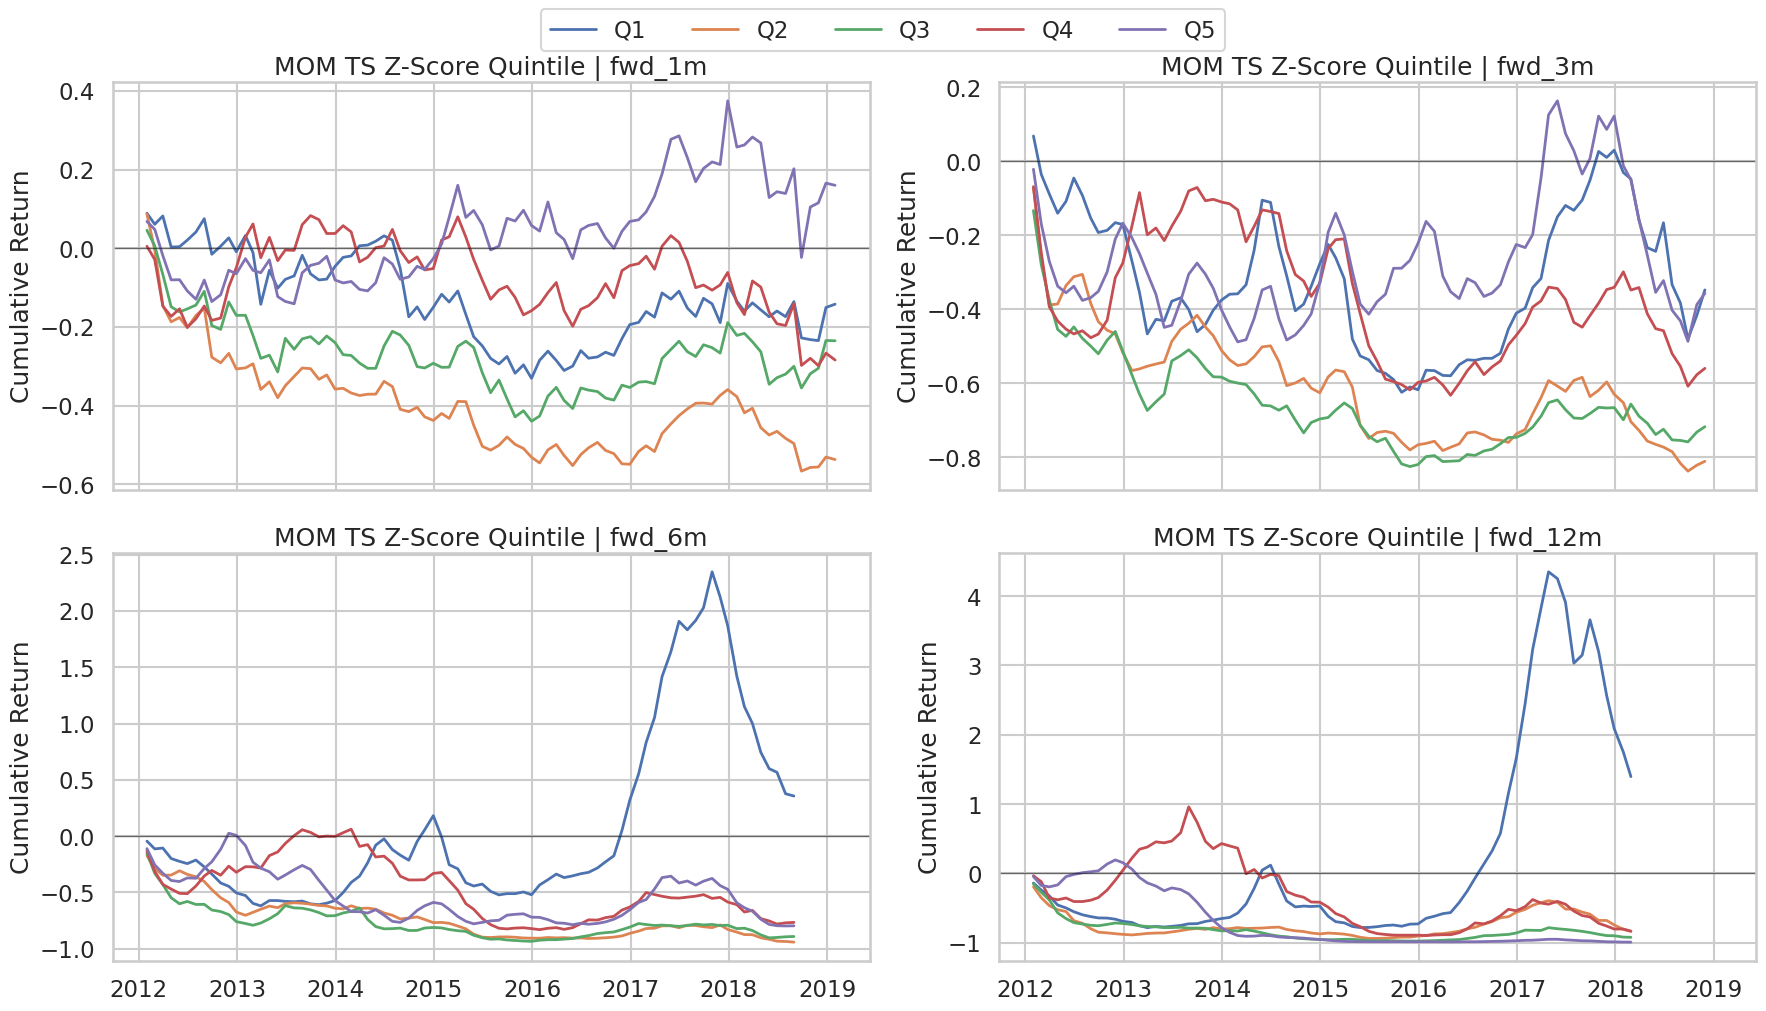

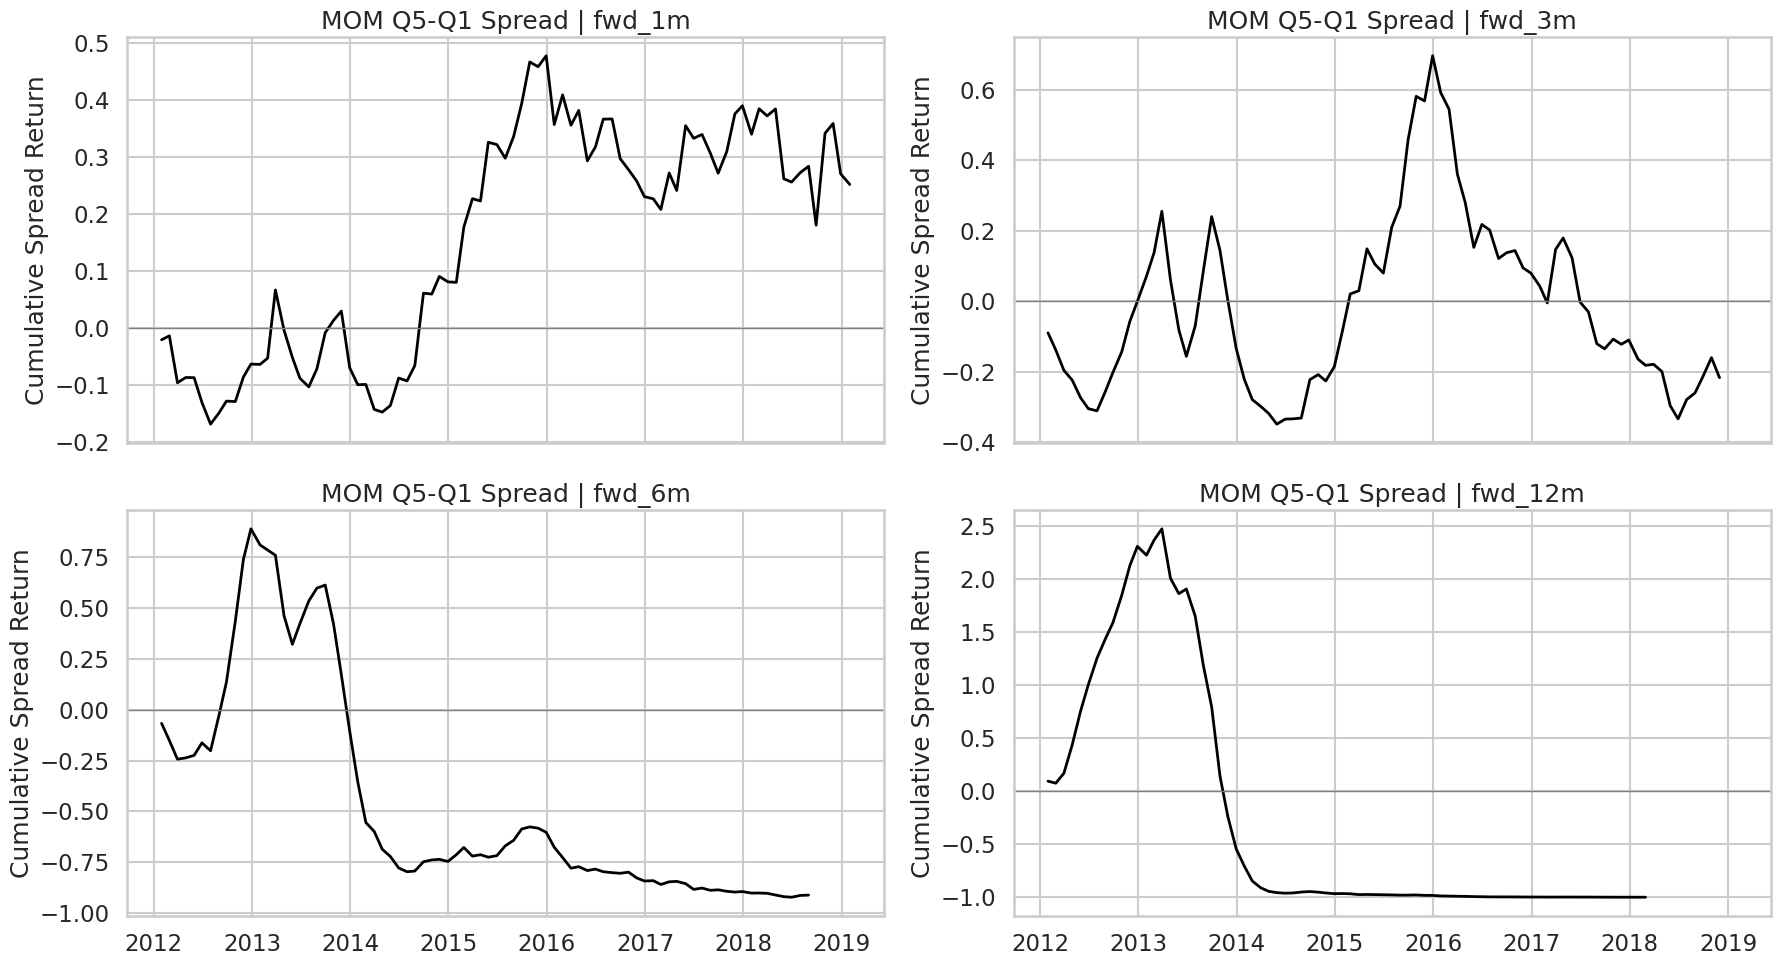

In [33]:
plot_quintile_trend(mom_agg_ts, "mom_ts_z_q", "MOM TS Z-Score Quintile")

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)
axes = axes.flatten()

for ax, h in zip(axes, HORIZONS):
    horizon = f"fwd_{h}m"
    sub = mom_agg_ts[mom_agg_ts["horizon"] == horizon]
    pivot = sub.pivot(index="date", columns="mom_ts_z_q", values="mean_return").sort_index()

    if "Q5" in pivot.columns and "Q1" in pivot.columns:
        spread = pivot["Q5"] - pivot["Q1"]
        spread_cum = (1.0 + spread.fillna(0.0)).cumprod() - 1.0
        ax.plot(spread_cum.index, spread_cum, color="black", linewidth=2)

    ax.set_title(f"MOM Q5-Q1 Spread | {horizon}")
    ax.axhline(0.0, color="gray", linewidth=1)
    ax.set_ylabel("Cumulative Spread Return")

fig.tight_layout()
plt.show()

## 8) 교차 검증 테이블 및 결과 저장 (CSV/Parquet)

요약 지표:
- 평균 수익률
- 승률 (수익률 > 0 비중)
- 최대/최소
- 표본 수

그리고 분석 결과와 핵심 파라미터를 저장합니다.

[TOP3 전략 성과 지표]


,TOP3_Strategy,섹터평균
months,85.000000,85.000000
total_return,-0.047310,-0.155733
CAGR,-0.006819,-0.023616
ann_vol,0.161438,0.137534
sharpe,0.039568,-0.104498
max_drawdown,-0.255888,-0.334410
hit_rate,0.541176,0.505882


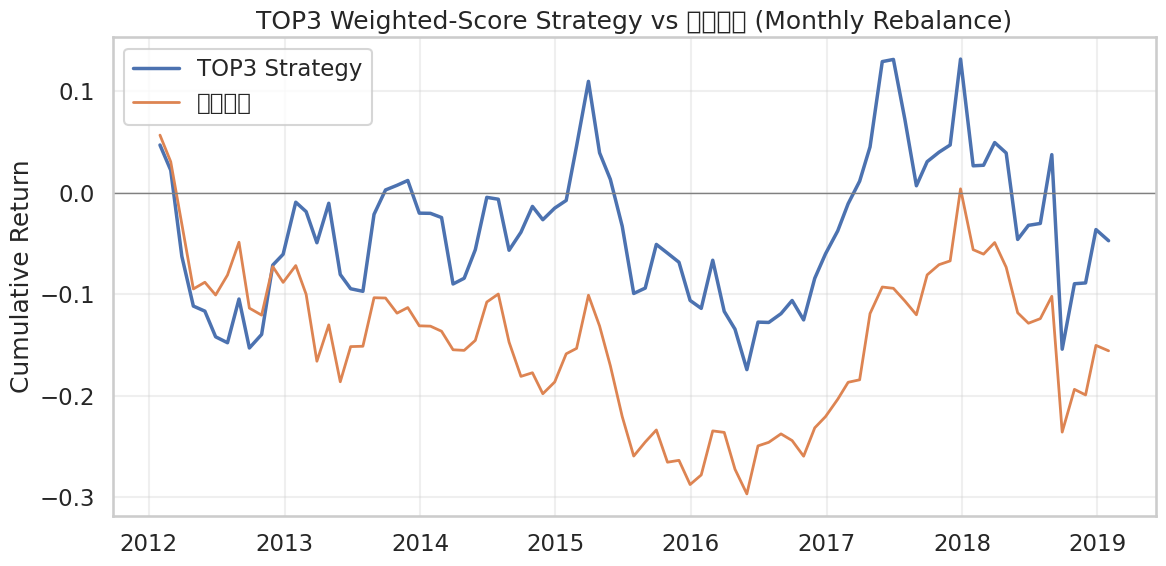

[현재 TOP3 산업] 기준 월말: 2019-02-08


,sector,combined_score,pbr_score,mom_score,pbr_quintile,mom_quintile
0,건설,1.000,1.00,1.00,Q5,Q5
1,운송,0.925,0.75,1.00,Q4,Q5
2,기계장비,0.750,0.75,0.75,Q4,Q4


Saved strategy files:
/workspaces/KR-Ind-Quant-Dashboard/outputs/top3_weighted_strategy_backtest.csv
/workspaces/KR-Ind-Quant-Dashboard/outputs/top3_weighted_strategy_current_top3.csv


In [34]:
# 분위 문자열(Q1~Q5) -> 숫자(1~5)
def quintile_to_num(df_q: pd.DataFrame) -> pd.DataFrame:
    return df_q.apply(lambda col: pd.to_numeric(col.astype(str).str.replace("Q", "", regex=False), errors="coerce"))


def perf_stats(monthly_ret: pd.Series) -> pd.Series:
    x = monthly_ret.dropna()
    n = len(x)
    if n == 0:
        return pd.Series(dtype=float)

    cum = (1.0 + x).cumprod()
    cagr = cum.iloc[-1] ** (12 / n) - 1
    vol = x.std(ddof=1) * np.sqrt(12) if n > 1 else np.nan
    sharpe = (x.mean() / x.std(ddof=1) * np.sqrt(12)) if (n > 1 and x.std(ddof=1) > 0) else np.nan
    mdd = (cum / cum.cummax() - 1.0).min()

    return pd.Series(
        {
            "months": n,
            "total_return": cum.iloc[-1] - 1,
            "CAGR": cagr,
            "ann_vol": vol,
            "sharpe": sharpe,
            "max_drawdown": mdd,
            "hit_rate": (x > 0).mean(),
        }
    )


# 1) 점수 산출
pbr_q_num = quintile_to_num(pbr_quintile)
mom_q_num = quintile_to_num(mom_quintile)

# PBR: Q5가 최고점
pbr_score = (pbr_q_num - 1.0) / 4.0
pbr_score = pbr_score.clip(lower=0.0, upper=1.0)

# MOM: Q5가 최고점
mom_score = (mom_q_num - 1.0) / 4.0
mom_score = mom_score.clip(lower=0.0, upper=1.0)

combined_score = 0.3 * pbr_score + 0.7 * mom_score

# 2) 월별 TOP3 선정 + 다음 1개월 수익률
strategy_rows = []
for dt in combined_score.index:
    score_row = combined_score.loc[dt].dropna().sort_values(ascending=False)
    if len(score_row) < 3:
        continue

    top3 = score_row.head(3).index.tolist()

    if dt not in forward_returns[1].index:
        continue

    fwd_ret = forward_returns[1].loc[dt, top3].dropna()
    if len(fwd_ret) == 0:
        continue

    strategy_rows.append(
        {
            "formation_date": dt,
            "top1": top3[0],
            "top2": top3[1],
            "top3": top3[2],
            "strategy_ret_1m": fwd_ret.mean(),
            "avg_score": score_row.head(3).mean(),
        }
    )

strategy_df = pd.DataFrame(strategy_rows).sort_values("formation_date").reset_index(drop=True)
strategy_df["formation_date"] = pd.to_datetime(strategy_df["formation_date"])
strategy_df = strategy_df.set_index("formation_date")

# 3) 한국 벤치마크(섹터 단순평균) 동일 구간/동일 방식(formation t -> t+1)
benchmark_df = forward_returns[1].mean(axis=1, skipna=True).to_frame("krx_benchmark_fwd_1m")

backtest = strategy_df.join(benchmark_df, how="inner")
backtest = backtest.dropna(subset=["strategy_ret_1m", "krx_benchmark_fwd_1m"])

backtest["strategy_cum"] = (1.0 + backtest["strategy_ret_1m"]).cumprod() - 1.0
backtest["benchmark_cum"] = (1.0 + backtest["krx_benchmark_fwd_1m"]).cumprod() - 1.0

# 4) 성과 지표
perf_table = pd.concat(
    [
        perf_stats(backtest["strategy_ret_1m"]).rename("TOP3_Strategy"),
        perf_stats(backtest["krx_benchmark_fwd_1m"]).rename(BENCHMARK_NAME),
    ],
    axis=1,
 )

print("[TOP3 전략 성과 지표]")
display(perf_table)

# 5) 누적성과 비교 그래프
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(backtest.index, backtest["strategy_cum"], label="TOP3 Strategy", linewidth=2.5)
ax.plot(backtest.index, backtest["benchmark_cum"], label=BENCHMARK_NAME, linewidth=2.0)
ax.axhline(0.0, color="gray", linewidth=1)
ax.set_title(f"TOP3 Weighted-Score Strategy vs {BENCHMARK_NAME} (Monthly Rebalance)")
ax.set_ylabel("Cumulative Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6) 현재(최신 formation 월) TOP3 산업
latest_dt = combined_score.dropna(how="all").index.max()
latest_rank = combined_score.loc[latest_dt].dropna().sort_values(ascending=False)
latest_top3 = latest_rank.head(3)

current_top3_df = pd.DataFrame(
    {
        "sector": latest_top3.index,
        "combined_score": latest_top3.values,
        "pbr_score": pbr_score.loc[latest_dt, latest_top3.index].values,
        "mom_score": mom_score.loc[latest_dt, latest_top3.index].values,
        "pbr_quintile": pbr_quintile.loc[latest_dt, latest_top3.index].values,
        "mom_quintile": mom_quintile.loc[latest_dt, latest_top3.index].values,
    }
)

print(f"[현재 TOP3 산업] 기준 월말: {latest_dt.date()}")
display(current_top3_df)

# 7) 저장
backtest.reset_index().to_csv(OUTPUT_DIR / "top3_weighted_strategy_backtest.csv", index=False)
current_top3_df.to_csv(OUTPUT_DIR / "top3_weighted_strategy_current_top3.csv", index=False)
print("Saved strategy files:")
print(OUTPUT_DIR / "top3_weighted_strategy_backtest.csv")
print(OUTPUT_DIR / "top3_weighted_strategy_current_top3.csv")

## 9) 가중 점수 기반 TOP3 전략 (월별 리밸런싱)

점수 규칙:
- PBR 점수: Q5에 가까울수록 높음
- MOM 점수: Q5에 가까울수록 높음
- 최종점수: `0.3 * PBR_score + 0.7 * MOM_score`

전략 규칙:
- 매월 월말에 최종점수 상위 3개 산업 동일가중 투자
- 다음 1개월 수익률로 성과 집계
- S&P500과 비교
- 최신 월 기준 현재 TOP3 산업 확인

In [35]:
# 분위 문자열(Q1~Q5) -> 숫자(1~5)
def quintile_to_num(df_q: pd.DataFrame) -> pd.DataFrame:
    return df_q.apply(lambda col: pd.to_numeric(col.astype(str).str.replace("Q", "", regex=False), errors="coerce"))


def perf_stats(monthly_ret: pd.Series) -> pd.Series:
    x = monthly_ret.dropna()
    n = len(x)
    if n == 0:
        return pd.Series(dtype=float)

    cum = (1.0 + x).cumprod()
    cagr = cum.iloc[-1] ** (12 / n) - 1
    vol = x.std(ddof=1) * np.sqrt(12) if n > 1 else np.nan
    sharpe = (x.mean() / x.std(ddof=1) * np.sqrt(12)) if (n > 1 and x.std(ddof=1) > 0) else np.nan
    mdd = (cum / cum.cummax() - 1.0).min()

    return pd.Series(
        {
            "months": n,
            "total_return": cum.iloc[-1] - 1,
            "CAGR": cagr,
            "ann_vol": vol,
            "sharpe": sharpe,
            "max_drawdown": mdd,
            "hit_rate": (x > 0).mean(),
        }
    )


# 1) 점수 산출
pbr_q_num = quintile_to_num(pbr_quintile)
mom_q_num = quintile_to_num(mom_quintile)

# PBR: Q5가 최고점
pbr_score = (pbr_q_num - 1.0) / 4.0
pbr_score = pbr_score.clip(lower=0.0, upper=1.0)

# MOM: Q5가 최고점
mom_score = (mom_q_num - 1.0) / 4.0
mom_score = mom_score.clip(lower=0.0, upper=1.0)

combined_score = 0.3 * pbr_score + 0.7 * mom_score

# 2) 월별 TOP3 선정 + 다음 1개월 수익률
strategy_rows = []
for dt in combined_score.index:
    score_row = combined_score.loc[dt].dropna().sort_values(ascending=False)
    if len(score_row) < 3:
        continue

    top3 = score_row.head(3).index.tolist()

    if dt not in forward_returns[1].index:
        continue

    fwd_ret = forward_returns[1].loc[dt, top3].dropna()
    if len(fwd_ret) == 0:
        continue

    strategy_rows.append(
        {
            "formation_date": dt,
            "top1": top3[0],
            "top2": top3[1],
            "top3": top3[2],
            "strategy_ret_1m": fwd_ret.mean(),
            "avg_score": score_row.head(3).mean(),
        }
    )

strategy_df = pd.DataFrame(strategy_rows).sort_values("formation_date").reset_index(drop=True)
strategy_df["formation_date"] = pd.to_datetime(strategy_df["formation_date"])
strategy_df = strategy_df.set_index("formation_date")

# 3) S&P500 동일 구간/동일 방식(formation t -> t+1) 수익률
sp500 = pd.read_csv(BASE_DIR / "sp500_monthly.csv", parse_dates=["Date"]).rename(columns={"Date": "date", "^GSPC": "sp500"})
sp500 = sp500.sort_values("date").set_index("date")
sp500["sp500_fwd_1m"] = sp500["sp500"].shift(-1) / sp500["sp500"] - 1.0

backtest = strategy_df.join(sp500[["sp500_fwd_1m"]], how="inner")
backtest = backtest.dropna(subset=["strategy_ret_1m", "sp500_fwd_1m"])

backtest["strategy_cum"] = (1.0 + backtest["strategy_ret_1m"]).cumprod() - 1.0
backtest["sp500_cum"] = (1.0 + backtest["sp500_fwd_1m"]).cumprod() - 1.0

# 4) 성과 지표
perf_table = pd.concat(
    [
        perf_stats(backtest["strategy_ret_1m"]).rename("TOP3_Strategy"),
        perf_stats(backtest["sp500_fwd_1m"]).rename("S&P500"),
    ],
    axis=1,
 )

print("[TOP3 전략 성과 지표]")
display(perf_table)

# 5) 누적성과 비교 그래프
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(backtest.index, backtest["strategy_cum"], label="TOP3 Strategy", linewidth=2.5)
ax.plot(backtest.index, backtest["sp500_cum"], label="S&P500", linewidth=2.0)
ax.axhline(0.0, color="gray", linewidth=1)
ax.set_title("TOP3 Weighted-Score Strategy vs S&P500 (Monthly Rebalance)")
ax.set_ylabel("Cumulative Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6) 현재(최신 formation 월) TOP3 산업
latest_dt = combined_score.dropna(how="all").index.max()
latest_rank = combined_score.loc[latest_dt].dropna().sort_values(ascending=False)
latest_top3 = latest_rank.head(3)

current_top3_df = pd.DataFrame(
    {
        "sector": latest_top3.index,
        "combined_score": latest_top3.values,
        "pbr_score": pbr_score.loc[latest_dt, latest_top3.index].values,
        "mom_score": mom_score.loc[latest_dt, latest_top3.index].values,
        "pbr_quintile": pbr_quintile.loc[latest_dt, latest_top3.index].values,
        "mom_quintile": mom_quintile.loc[latest_dt, latest_top3.index].values,
    }
)

print(f"[현재 TOP3 산업] 기준 월말: {latest_dt.date()}")
display(current_top3_df)

# 7) 저장
backtest.reset_index().to_csv(OUTPUT_DIR / "top3_weighted_strategy_backtest.csv", index=False)
current_top3_df.to_csv(OUTPUT_DIR / "top3_weighted_strategy_current_top3.csv", index=False)
print("Saved strategy files:")
print(OUTPUT_DIR / "top3_weighted_strategy_backtest.csv")
print(OUTPUT_DIR / "top3_weighted_strategy_current_top3.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/KR-Ind-Quant-Dashboard/sp500_monthly.csv'

## 9-1) 가중 점수 기반 TOP5 전략 (월별 리밸런싱)

동일한 점수 체계( `0.3 * PBR + 0.7 * MOM` )를 사용하되,
매월 상위 5개 산업을 동일가중으로 구성한 TOP5 전략을 추가로 비교합니다.

[TOP5 전략 성과 지표]


,TOP5_Strategy,S&P500
months,51.000000,51.000000
total_return,1.386721,0.842622
CAGR,0.227141,0.154664
ann_vol,0.174553,0.176818
sharpe,1.266800,0.904933
max_drawdown,-0.124698,-0.214394
hit_rate,0.627451,0.647059


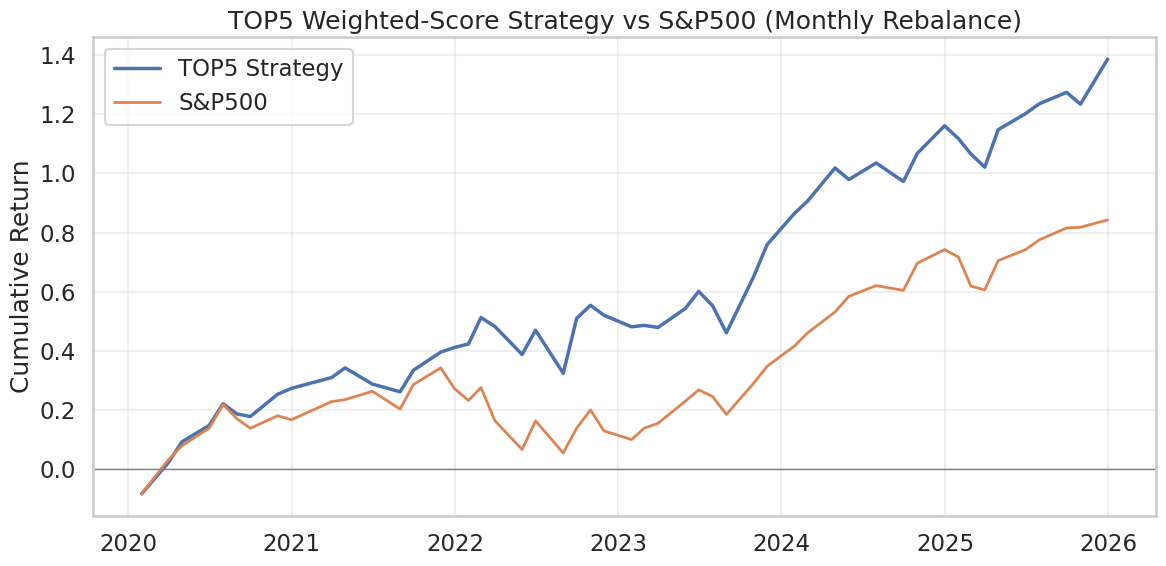

[현재 TOP5 산업] 기준 월말: 2026-03-20


,sector,combined_score,pbr_score,mom_score,pbr_quintile,mom_quintile
0,자동차와부품,1.000,1.00,1.00,Q5,Q5
1,에너지산업,1.000,1.00,1.00,Q5,Q5
2,기술 하드웨어,0.925,0.75,1.00,Q4,Q5
3,제약생명공학,0.850,0.50,1.00,Q3,Q5
4,자본재산업,0.825,1.00,0.75,Q5,Q4


Saved TOP5 strategy files:
/workspaces/ETF_statar/outputs/top5_weighted_strategy_backtest.csv
/workspaces/ETF_statar/outputs/top5_weighted_strategy_current_top5.csv


In [ ]:
# 1) 월별 TOP5 선정 + 다음 1개월 수익률
strategy5_rows = []
for dt in combined_score.index:
    score_row = combined_score.loc[dt].dropna().sort_values(ascending=False)
    if len(score_row) < 5:
        continue

    top5 = score_row.head(5).index.tolist()

    if dt not in forward_returns[1].index:
        continue

    fwd_ret = forward_returns[1].loc[dt, top5].dropna()
    if len(fwd_ret) == 0:
        continue

    strategy5_rows.append(
        {
            "formation_date": dt,
            "top1": top5[0],
            "top2": top5[1],
            "top3": top5[2],
            "top4": top5[3],
            "top5": top5[4],
            "strategy_ret_1m": fwd_ret.mean(),
            "avg_score": score_row.head(5).mean(),
        }
    )

strategy5_df = pd.DataFrame(strategy5_rows).sort_values("formation_date").reset_index(drop=True)
strategy5_df["formation_date"] = pd.to_datetime(strategy5_df["formation_date"])
strategy5_df = strategy5_df.set_index("formation_date")

# 2) 한국 벤치마크 동일 구간/동일 방식(formation t -> t+1) 수익률
backtest5 = strategy5_df.join(benchmark_df[["krx_benchmark_fwd_1m"]], how="inner")
backtest5 = backtest5.dropna(subset=["strategy_ret_1m", "krx_benchmark_fwd_1m"])

backtest5["strategy_cum"] = (1.0 + backtest5["strategy_ret_1m"]).cumprod() - 1.0
backtest5["benchmark_cum"] = (1.0 + backtest5["krx_benchmark_fwd_1m"]).cumprod() - 1.0

# 3) 성과 지표
perf5_table = pd.concat(
    [
        perf_stats(backtest5["strategy_ret_1m"]).rename("TOP5_Strategy"),
        perf_stats(backtest5["krx_benchmark_fwd_1m"]).rename(BENCHMARK_NAME),
    ],
    axis=1,
 )

print("[TOP5 전략 성과 지표]")
display(perf5_table)

# 4) 누적성과 비교 그래프
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(backtest5.index, backtest5["strategy_cum"], label="TOP5 Strategy", linewidth=2.5)
ax.plot(backtest5.index, backtest5["benchmark_cum"], label=BENCHMARK_NAME, linewidth=2.0)
ax.axhline(0.0, color="gray", linewidth=1)
ax.set_title(f"TOP5 Weighted-Score Strategy vs {BENCHMARK_NAME} (Monthly Rebalance)")
ax.set_ylabel("Cumulative Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5) 현재(최신 formation 월) TOP5 산업
latest_dt5 = combined_score.dropna(how="all").index.max()
latest_rank5 = combined_score.loc[latest_dt5].dropna().sort_values(ascending=False)
latest_top5 = latest_rank5.head(5)

current_top5_df = pd.DataFrame(
    {
        "sector": latest_top5.index,
        "combined_score": latest_top5.values,
        "pbr_score": pbr_score.loc[latest_dt5, latest_top5.index].values,
        "mom_score": mom_score.loc[latest_dt5, latest_top5.index].values,
        "pbr_quintile": pbr_quintile.loc[latest_dt5, latest_top5.index].values,
        "mom_quintile": mom_quintile.loc[latest_dt5, latest_top5.index].values,
    }
)

print(f"[현재 TOP5 산업] 기준 월말: {latest_dt5.date()}")
display(current_top5_df)

# 6) 저장
backtest5.reset_index().to_csv(OUTPUT_DIR / "top5_weighted_strategy_backtest.csv", index=False)
current_top5_df.to_csv(OUTPUT_DIR / "top5_weighted_strategy_current_top5.csv", index=False)
print("Saved TOP5 strategy files:")
print(OUTPUT_DIR / "top5_weighted_strategy_backtest.csv")
print(OUTPUT_DIR / "top5_weighted_strategy_current_top5.csv")

## 9-2) 거래비용 30bp 반영 성과 (TOP3 / TOP5)

가정: 월별 리밸런싱 시 전략 수익률에서 **30bp(0.30%)**를 차감합니다.
- `net_ret_1m = gross_ret_1m - 0.003`
- 벤치마크(S&P500)는 거래비용 차감 없이 그대로 비교합니다.

[거래비용 반영 기준] 30bp (월별)

TOP3 성과 비교


,TOP3_gross,TOP3_net_30bp,S&P500
months,51.000000,51.000000,51.000000
total_return,1.756374,1.371461,0.842622
CAGR,0.269431,0.225291,0.154664
ann_vol,0.183728,0.183728,0.176818
sharpe,1.399743,1.203802,0.904933
max_drawdown,-0.144094,-0.154743,-0.214394
hit_rate,0.627451,0.607843,0.647059



TOP5 성과 비교


,TOP5_gross,TOP5_net_30bp,S&P500
months,51.000000,51.000000,51.000000
total_return,1.386721,1.052592,0.842622
CAGR,0.227141,0.184358,0.154664
ann_vol,0.174553,0.174553,0.176818
sharpe,1.266800,1.060559,0.904933
max_drawdown,-0.124698,-0.135527,-0.214394
hit_rate,0.627451,0.627451,0.647059


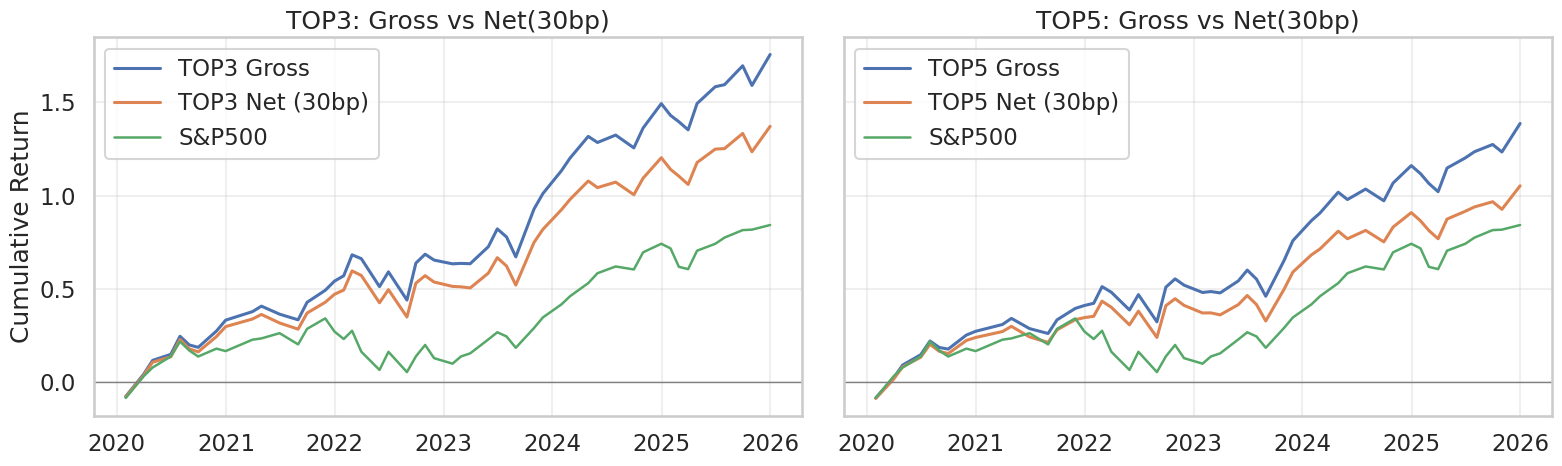

Saved TC files:
/workspaces/ETF_statar/outputs/top3_weighted_strategy_perf_tc30bp.csv
/workspaces/ETF_statar/outputs/top5_weighted_strategy_perf_tc30bp.csv
/workspaces/ETF_statar/outputs/top3_weighted_strategy_backtest_tc30bp.csv
/workspaces/ETF_statar/outputs/top5_weighted_strategy_backtest_tc30bp.csv


In [ ]:
TC_BPS = 30
TC_RATE = TC_BPS / 10000.0  # 30bp = 0.003

# 1) TOP3 거래비용 반영
backtest_tc3 = backtest.copy()
backtest_tc3["strategy_ret_1m_net"] = backtest_tc3["strategy_ret_1m"] - TC_RATE
backtest_tc3["strategy_cum_net"] = (1.0 + backtest_tc3["strategy_ret_1m_net"]).cumprod() - 1.0

# 2) TOP5 거래비용 반영
backtest_tc5 = backtest5.copy()
backtest_tc5["strategy_ret_1m_net"] = backtest_tc5["strategy_ret_1m"] - TC_RATE
backtest_tc5["strategy_cum_net"] = (1.0 + backtest_tc5["strategy_ret_1m_net"]).cumprod() - 1.0

# 3) 성과 지표 비교
perf_tc3 = pd.concat(
    [
        perf_stats(backtest_tc3["strategy_ret_1m"]).rename("TOP3_gross"),
        perf_stats(backtest_tc3["strategy_ret_1m_net"]).rename("TOP3_net_30bp"),
        perf_stats(backtest_tc3["krx_benchmark_fwd_1m"]).rename(BENCHMARK_NAME),
    ],
    axis=1,
 )

perf_tc5 = pd.concat(
    [
        perf_stats(backtest_tc5["strategy_ret_1m"]).rename("TOP5_gross"),
        perf_stats(backtest_tc5["strategy_ret_1m_net"]).rename("TOP5_net_30bp"),
        perf_stats(backtest_tc5["krx_benchmark_fwd_1m"]).rename(BENCHMARK_NAME),
    ],
    axis=1,
 )

print(f"[거래비용 반영 기준] {TC_BPS}bp (월별)")
print("\nTOP3 성과 비교")
display(perf_tc3)
print("\nTOP5 성과 비교")
display(perf_tc5)

# 4) 누적수익률 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

axes[0].plot(backtest_tc3.index, backtest_tc3["strategy_cum"], label="TOP3 Gross", linewidth=2.2)
axes[0].plot(backtest_tc3.index, backtest_tc3["strategy_cum_net"], label="TOP3 Net (30bp)", linewidth=2.2)
axes[0].plot(backtest_tc3.index, backtest_tc3["benchmark_cum"], label=BENCHMARK_NAME, linewidth=1.8)
axes[0].axhline(0.0, color="gray", linewidth=1)
axes[0].set_title("TOP3: Gross vs Net(30bp)")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(backtest_tc5.index, backtest_tc5["strategy_cum"], label="TOP5 Gross", linewidth=2.2)
axes[1].plot(backtest_tc5.index, backtest_tc5["strategy_cum_net"], label="TOP5 Net (30bp)", linewidth=2.2)
axes[1].plot(backtest_tc5.index, backtest_tc5["benchmark_cum"], label=BENCHMARK_NAME, linewidth=1.8)
axes[1].axhline(0.0, color="gray", linewidth=1)
axes[1].set_title("TOP5: Gross vs Net(30bp)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5) 저장
perf_tc3.to_csv(OUTPUT_DIR / "top3_weighted_strategy_perf_tc30bp.csv")
perf_tc5.to_csv(OUTPUT_DIR / "top5_weighted_strategy_perf_tc30bp.csv")
backtest_tc3.reset_index().to_csv(OUTPUT_DIR / "top3_weighted_strategy_backtest_tc30bp.csv", index=False)
backtest_tc5.reset_index().to_csv(OUTPUT_DIR / "top5_weighted_strategy_backtest_tc30bp.csv", index=False)

print("Saved TC files:")
print(OUTPUT_DIR / "top3_weighted_strategy_perf_tc30bp.csv")
print(OUTPUT_DIR / "top5_weighted_strategy_perf_tc30bp.csv")
print(OUTPUT_DIR / "top3_weighted_strategy_backtest_tc30bp.csv")
print(OUTPUT_DIR / "top5_weighted_strategy_backtest_tc30bp.csv")

## 9-3) 장기 백테스트 (신호 가능 전체 기간)

2020년 이후 구간이 아닌, **신호 계산이 가능한 전체 기간**으로 전략을 재검증합니다.
- 동일 점수 체계: `0.3 * PBR(Q5 우대) + 0.7 * MOM(Q5 우대)`
- TOP3 / TOP5 월별 리밸런싱
- S&P500 대비 장기 초과성과 확인

[장기 백테스트 성과]
기간: 2003-01-31 ~ 2025-12-31


,TOP3_Long,TOP5_Long,S&P500_Long
months,195.000000,195.000000,195.000000
total_return,4.831892,6.869360,4.278978
CAGR,0.114620,0.135363,0.107808
ann_vol,0.178413,0.160002,0.146558
sharpe,0.700699,0.877943,0.775193
max_drawdown,-0.517025,-0.384119,-0.363574
hit_rate,0.630769,0.641026,0.666667



[장기 초과성과 요약: 전략 - S&P500]


,metric,TOP3_minus_SP500,TOP5_minus_SP500
0,total_return,0.552914,2.590382
1,CAGR,0.006811,0.027555
2,sharpe,-0.074494,0.102751
3,max_drawdown,-0.153451,-0.020545


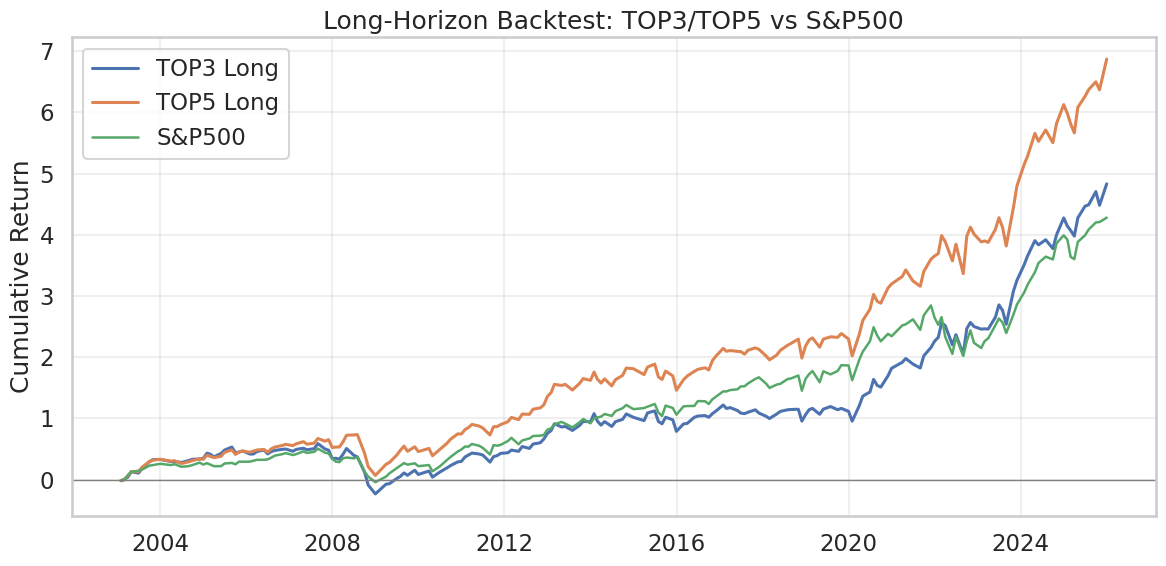

Saved long-horizon files:
/workspaces/ETF_statar/outputs/long_backtest_perf_summary.csv
/workspaces/ETF_statar/outputs/long_backtest_overperformance_summary.csv
/workspaces/ETF_statar/outputs/top3_weighted_strategy_backtest_long.csv
/workspaces/ETF_statar/outputs/top5_weighted_strategy_backtest_long.csv


In [ ]:
# 1) 전체 월말 인덱스(START_DATE 필터 미적용) 재구성
month_end_idx_all = (
    price_d.groupby(price_d.index.to_period("M"))
    .apply(lambda x: x.index.max())
)
month_end_idx_all = pd.DatetimeIndex(month_end_idx_all.values).sort_values()

# 2) 전체 기간 신호/미래수익률 구성
pbr_ts_z_all = pbr_ts_z_daily.loc[month_end_idx_all].copy()
mom_ts_z_all = mom_ts_z_daily.loc[month_end_idx_all].copy()
price_m_all = price_d.loc[month_end_idx_all].copy()
fwd_1m_all = price_m_all.shift(-1) / price_m_all - 1.0
benchmark_long = fwd_1m_all.mean(axis=1, skipna=True).to_frame("krx_benchmark_fwd_1m")

# 3) 전체 기간 분위 및 점수
pbr_quintile_all = pbr_ts_z_all.apply(assign_quintiles_row, axis=1, q=QUINTILES)
mom_quintile_all = mom_ts_z_all.apply(assign_quintiles_row, axis=1, q=QUINTILES)

pbr_q_num_all = quintile_to_num(pbr_quintile_all)
mom_q_num_all = quintile_to_num(mom_quintile_all)

pbr_score_all = ((pbr_q_num_all - 1.0) / 4.0).clip(lower=0.0, upper=1.0)
mom_score_all = ((mom_q_num_all - 1.0) / 4.0).clip(lower=0.0, upper=1.0)
combined_score_all = 0.3 * pbr_score_all + 0.7 * mom_score_all

# 4) TOP-N 공용 백테스트 함수
def run_topn_backtest(combined_df: pd.DataFrame, fwd_1m_df: pd.DataFrame, n_top: int) -> pd.DataFrame:
    rows = []
    for dt in combined_df.index:
        score_row = combined_df.loc[dt].dropna().sort_values(ascending=False)
        if len(score_row) < n_top:
            continue

        picks = score_row.head(n_top).index.tolist()
        if dt not in fwd_1m_df.index:
            continue

        ret = fwd_1m_df.loc[dt, picks].dropna()
        if len(ret) == 0:
            continue

        row = {
            "formation_date": dt,
            "strategy_ret_1m": ret.mean(),
            "avg_score": score_row.head(n_top).mean(),
        }
        for i, sec in enumerate(picks, start=1):
            row[f"top{i}"] = sec
        rows.append(row)

    out = pd.DataFrame(rows).sort_values("formation_date").reset_index(drop=True)
    out["formation_date"] = pd.to_datetime(out["formation_date"])
    return out.set_index("formation_date")

# 5) 장기 TOP3/TOP5 실행 + 한국 벤치마크 비교
long_bt3 = run_topn_backtest(combined_score_all, fwd_1m_all, 3)
long_bt5 = run_topn_backtest(combined_score_all, fwd_1m_all, 5)

long_bt3 = long_bt3.join(benchmark_long, how="inner").dropna(subset=["strategy_ret_1m", "krx_benchmark_fwd_1m"])
long_bt5 = long_bt5.join(benchmark_long, how="inner").dropna(subset=["strategy_ret_1m", "krx_benchmark_fwd_1m"])

long_bt3["strategy_cum"] = (1.0 + long_bt3["strategy_ret_1m"]).cumprod() - 1.0
long_bt3["benchmark_cum"] = (1.0 + long_bt3["krx_benchmark_fwd_1m"]).cumprod() - 1.0
long_bt5["strategy_cum"] = (1.0 + long_bt5["strategy_ret_1m"]).cumprod() - 1.0
long_bt5["benchmark_cum"] = (1.0 + long_bt5["krx_benchmark_fwd_1m"]).cumprod() - 1.0

perf_long = pd.concat(
    [
        perf_stats(long_bt3["strategy_ret_1m"]).rename("TOP3_Long"),
        perf_stats(long_bt5["strategy_ret_1m"]).rename("TOP5_Long"),
        perf_stats(long_bt3["krx_benchmark_fwd_1m"]).rename(f"{BENCHMARK_NAME}_Long"),
    ],
    axis=1,
 )

print("[장기 백테스트 성과]")
print("기간:", long_bt3.index.min().date(), "~", long_bt3.index.max().date())
display(perf_long)

# 6) 초과성과(Overperformance) 확인
benchmark_col = f"{BENCHMARK_NAME}_Long"
overperf_summary = pd.DataFrame(
    {
        "metric": ["total_return", "CAGR", "sharpe", "max_drawdown"],
        "TOP3_minus_Benchmark": [
            perf_long.loc["total_return", "TOP3_Long"] - perf_long.loc["total_return", benchmark_col],
            perf_long.loc["CAGR", "TOP3_Long"] - perf_long.loc["CAGR", benchmark_col],
            perf_long.loc["sharpe", "TOP3_Long"] - perf_long.loc["sharpe", benchmark_col],
            perf_long.loc["max_drawdown", "TOP3_Long"] - perf_long.loc["max_drawdown", benchmark_col],
        ],
        "TOP5_minus_Benchmark": [
            perf_long.loc["total_return", "TOP5_Long"] - perf_long.loc["total_return", benchmark_col],
            perf_long.loc["CAGR", "TOP5_Long"] - perf_long.loc["CAGR", benchmark_col],
            perf_long.loc["sharpe", "TOP5_Long"] - perf_long.loc["sharpe", benchmark_col],
            perf_long.loc["max_drawdown", "TOP5_Long"] - perf_long.loc["max_drawdown", benchmark_col],
        ],
    }
)
print(f"\n[장기 초과성과 요약: 전략 - {BENCHMARK_NAME}]")
display(overperf_summary)

# 7) 장기 누적성과 시각화
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(long_bt3.index, long_bt3["strategy_cum"], label="TOP3 Long", linewidth=2.2)
ax.plot(long_bt5.index, long_bt5["strategy_cum"], label="TOP5 Long", linewidth=2.2)
ax.plot(long_bt3.index, long_bt3["benchmark_cum"], label=BENCHMARK_NAME, linewidth=1.8)
ax.axhline(0.0, color="gray", linewidth=1)
ax.set_title(f"Long-Horizon Backtest: TOP3/TOP5 vs {BENCHMARK_NAME}")
ax.set_ylabel("Cumulative Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8) 저장
perf_long.to_csv(OUTPUT_DIR / "long_backtest_perf_summary.csv")
overperf_summary.to_csv(OUTPUT_DIR / "long_backtest_overperformance_summary.csv", index=False)
long_bt3.reset_index().to_csv(OUTPUT_DIR / "top3_weighted_strategy_backtest_long.csv", index=False)
long_bt5.reset_index().to_csv(OUTPUT_DIR / "top5_weighted_strategy_backtest_long.csv", index=False)

print("Saved long-horizon files:")
print(OUTPUT_DIR / "long_backtest_perf_summary.csv")
print(OUTPUT_DIR / "long_backtest_overperformance_summary.csv")
print(OUTPUT_DIR / "top3_weighted_strategy_backtest_long.csv")
print(OUTPUT_DIR / "top5_weighted_strategy_backtest_long.csv")

## 10) 향후 재사용용 권장 데이터셋 저장 (필터 유니버스 + Yahoo 매핑)

앞으로 다른 분석에 바로 쓸 수 있도록 아래 파일을 생성합니다.
- PBR: 제외 섹터 반영한 산업 패널
- 가격: Yahoo Finance ETF를 산업명으로 매핑한 패널
- (참고) 기존 로컬 가격의 동일 유니버스 패널

In [ ]:
# 1) PBR (필터 유니버스)
pbr_reusable = pbr_raw[common_sectors].copy().sort_index()
pbr_reusable.index.name = "date"

# 2) 로컬 ETF 가격 (필터 유니버스)
local_price_reusable = price_raw[common_sectors].copy().sort_index()
local_price_reusable.index.name = "date"

# 3) 월별 벤치마크(섹터 평균 1M FWD)
benchmark_reusable = benchmark_df.copy()
benchmark_reusable.index.name = "date"

# 4) 저장
pbr_reusable_path = OUTPUT_DIR / "sector_pbr_filtered.csv"
local_price_reusable_path = OUTPUT_DIR / "sector_price_local_filtered.csv"
benchmark_reusable_path = OUTPUT_DIR / "krx_sector_equal_weight_benchmark_fwd1m.csv"

pbr_reusable.to_csv(pbr_reusable_path)
local_price_reusable.to_csv(local_price_reusable_path)
benchmark_reusable.to_csv(benchmark_reusable_path)

print("Saved reusable datasets:")
print(pbr_reusable_path)
print(local_price_reusable_path)
print(benchmark_reusable_path)
print("\nShapes")
print("PBR:", pbr_reusable.shape)
print("Local filtered price:", local_price_reusable.shape)
print("Benchmark:", benchmark_reusable.shape)

display(local_price_reusable.tail(3))

Saved reusable datasets:
/workspaces/ETF_statar/outputs/sector_pbr_filtered.csv
/workspaces/ETF_statar/outputs/sector_price_yahoo_mapped_filtered.csv
/workspaces/ETF_statar/outputs/sector_price_local_filtered.csv

Shapes
PBR: (6580, 20)
Yahoo mapped price: (6586, 20)
Local filtered price: (6344, 20)


,기술 하드웨어,내구소비재,다각화금융,미디어산업,보험산업,소비자서비스,소프트웨어,식품,에너지산업,운송,원자재산업,유통산업,유틸리티,은행산업,음식료담배,자동차와부품,자본재산업,정보통신서비스,제약생명공학,헬스케어
date,,,,,,,,,,,,,,,,,,,,
2026-03-26,328.850006,358.359985,82.209999,50.159801,54.830002,57.869999,79.750000,48.700001,61.520000,73.699997,49.090000,79.959999,45.330002,59.090000,81.139999,29.910000,220.119995,108.809998,123.900002,145.740005
2026-03-27,323.480011,348.049988,80.120003,49.363300,53.549999,56.340000,76.889999,48.910000,62.560001,72.489998,48.910000,78.580002,45.590000,57.880001,81.779999,29.617001,216.039993,107.040001,119.589996,143.259995
2026-03-30,318.859985,350.290009,80.809998,NaN,53.880001,56.380001,77.979897,48.910000,63.165001,72.379997,49.314999,78.989998,45.959999,58.090000,81.730003,29.719999,213.929993,108.029999,119.709999,144.000000
